In [1]:
import numpy as np
import pickle
import os
import sys

%matplotlib inline
import matplotlib.pyplot as plt

# sys.path.append('./preprocess_data')
# from utils import plot_events_rate

# Add the parent directory to the system path
sys.path.append(os.path.abspath(os.path.join(os.path.dirname(os.getcwd()))))

from eb_dataset import EB_DS, EB_DS_batched, load_dataset


In [2]:
!ls ../../datasets/eb_datasets

20240101  20240119    20240628	20240711_1  20250714_2	20250803    20250810_2
20240102  20240317    20240630	20240711_2  20250715	20250805    20250909
20240103  20240320    20240702	20240728    20250722	20250805_2  20250911
20240107  20240407    20240703	20240801    20250724	20250806_1  20251008
20240110  20240413    20240705	20240820    20250728	20250806_2
20240111  20240619_1  20240707	20250710    20250729	20250807
20240117  20240621    20240708	20250713    20250730_1	20250809
20240118  20240623    20240710	20250714_1  20250730_2	20250810_1


## Load data

In [10]:
# test evk4 dataset load
import sys
import os

# Add the parent directory to the system path
sys.path.append(os.path.abspath(os.path.join(os.path.dirname(os.getcwd()))))

from eb_dataset import EB_DS, EB_DS_batched, load_dataset

# ROI_w=61 # original frame size 
# ROI_h=41
# n_samples = 48
# ds_path = os.path.abspath('../../evk4_data_analysis/preprocess_data/pkl_ds/train/')
# ds, labels, _ = load_dataset(base_path=ds_path, n_samples=n_samples, shuffle_order=None, jitter_ts=0.0, do_shuffle=False,
#                                         imu_channels=None, time_align_by_imu_edge= False, field_names= ['t','x','y','p'], polarity_filter=None)

ROI_w=61 # original frame size 
ROI_h=61
n_samples=96
# ds_path = os.path.abspath('/shareds/eb_datasets/20240623/train/')
ds_path = os.path.abspath('../../datasets/eb_datasets/20250909/train')
ds, labels, shuffle_order = load_dataset(base_path=ds_path, n_samples=n_samples, shuffle_order=None, jitter_ts=0.0,
                                        imu_channels=None, time_align_by_imu_edge= False, polarity_filter=None)

imu_file_path = os.path.join(ds_path,'imu.pkl')
with open(imu_file_path, 'rb') as f:
    imu_traces = pickle.load(f)

# imu_traces_ = []
# for trace in imu_traces:
#     trace = trace['gyroscope1']
#     imu_traces_.append(trace)
# imu_traces = imu_traces_

# imu_traces = [imu_traces[i] for i in shuffle_order]

print(f"Data loaded with {len(ds)} samples.")

train_dataset = EB_DS(ds, labels, n_samples=n_samples, shuffle_events = False, start_time=100.0)
print(f"train dataset generated with {len(train_dataset)} samples.")

def get_trial_data(index):
    # return train_dataset[index][0], imu_traces[shuffle_order[index]]
    return train_dataset[index][0], imu_traces[index], ds[index]

loading /home/labs/ahissarlab/bnassa/datasets/eb_datasets/20250909/train/events.pkl...
/home/labs/ahissarlab/bnassa/datasets/eb_datasets/20250909/train/labels.pkl
Data loaded with 60000 samples.
train dataset generated with 60000 samples.


## Display single trial data

In [11]:
def plot_events_heat_map(events, plt_ax, time_wnd = None, spatial_wnd = None, polarity = None):
    events_ = events
    
    # temporal window
    if time_wnd is not None:
        events_ = events_[events_['t']>time_wnd[0]]
        events_ = events_[events_['t']<time_wnd[1]]
    
    # spatial window
    if spatial_wnd is not None:
        events_ = events_[events_['x']>spatial_wnd[0]]
        events_ = events_[events_['x']<spatial_wnd[1]]
        events_ = events_[events_['y']>spatial_wnd[2]]
        events_ = events_[events_['y']<spatial_wnd[3]]
        
    if polarity is not None:
        events_ = events_[events_[:,3]==polarity]
    
    # print("Events #: ", events_.shape[0])
    # print('2D histogram:')
    # plt.figure()
    hist = plt_ax.hist2d(events_[:,1], events_[:,2], 
                      bins=(ROI_w, ROI_h), 
                      range=[[0,ROI_w-1], [0,ROI_h-1]], cmap='jet') # 'Blues', 'plasma', 'jet'
    cb = plt.colorbar(hist[3], ax = plt_ax)
    cb.set_label('counts in bin')
    # plt.show()

def plot_events_rate(events, imu_data = None, ax_events=None, ax_imu = None, bin_size=1, space_crop = None, time_crop = None):
    
    timestamps = events[:,0]
    
    if space_crop is not None:
        timestamps = timestamps[np.logical_and(np.logical_and(events['x']>=space_crop[0], 
                                                              events['x']<space_crop[2]),
                                               np.logical_and(events['y']>=space_crop[1],
                                                              events['y']<space_crop[3]))]
                                               
    if time_crop is not None:
        timestamps = timestamps[np.logical_and(timestamps>=time_crop[0], timestamps<time_crop[1])]
    
    #filter polarity
    #timestamps = timestamps[events['polarity']==0]

    if (timestamps.shape[0]>=1):
        nbins = int((timestamps[-1] - timestamps[0])//bin_size)
    else:
        nbins = 1
        
    #print(nbins)
    if ax_events is not None:
        hist_n = ax_events.hist(timestamps, nbins)
    else:
        plt.gca().hist(timestamps, nbins)
    
    #moving average
    #cumsum = np.cumsum(hist_n[0])
    #moving_avg = (cumsum[7:]-cumsum[:-7])/7
    #axs[1].plot(hist_n[1][4:-4], moving_avg)
    #axs[1].set_xlim([0, motion_end_ts-motio
    #moving average
    
    if imu_data is not None and ax_imu is not None:
        ax_imu.plot(imu_data['timestamp'], imu_data['gyroscope0'],'b')
        ax_imu.plot(imu_data['timestamp'], imu_data['gyroscope1'],'r')
        ax_imu.plot(imu_data['timestamp'], imu_data['gyroscope2'],'g')
        ax_events.set_xlim(ax_imu.get_xlim())
        
def get_event_rate(events, bins=range(0,400,1), space_crop = None, time_crop = None):
    
    timestamps = events[:,0]
    
    if space_crop is not None:
        timestamps = timestamps[np.logical_and(np.logical_and(events[:,1]>=space_crop[0], 
                                                              events[:,1]<space_crop[2]),
                                               np.logical_and(events[:,2]>=space_crop[1],
                                                              events[:,2]<space_crop[3]))]
                                               
    if time_crop is not None:
        timestamps = timestamps[np.logical_and(timestamps>=time_crop[0], timestamps<time_crop[1])]
    
    rate,_ = np.histogram(timestamps, bins=bins)
        
    return rate

96
301


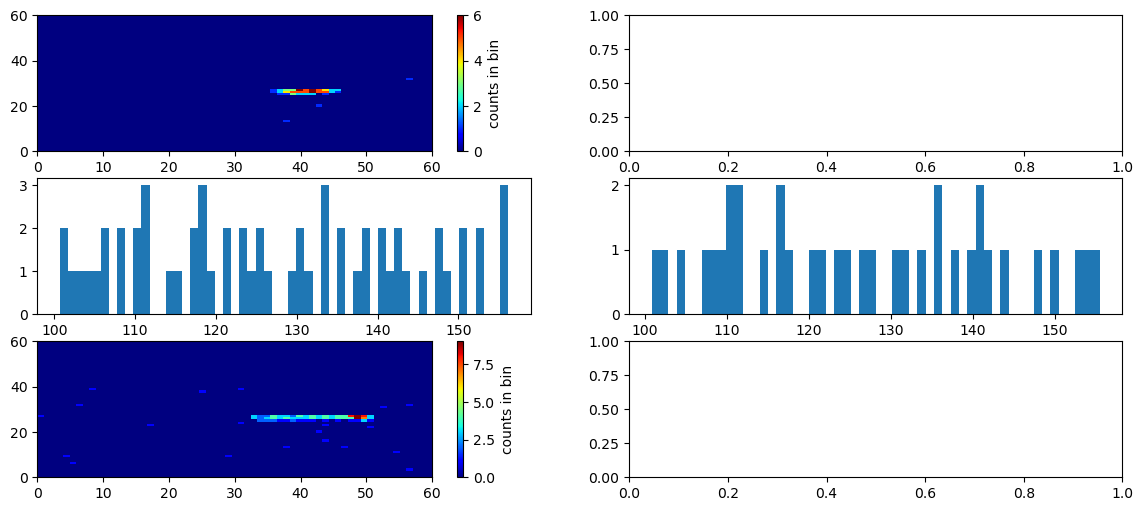

In [12]:
# evnts, imu_trace, evnts_raw = get_trial_data(4335)
# evnts, imu_trace, evnts_raw = get_trial_data(5114)
evnts, imu_trace, evnts_raw = get_trial_data(10000)

#remove padding
evnts = evnts[evnts[:,0]!=0,:]
print(evnts.shape[0])
print(evnts_raw.shape[0])

fig, axs = plt.subplots(3, 2, figsize=(14,6))
plot_events_heat_map(evnts, axs[0,0])
# axs[0,1].plot(np.arange(len(imu_trace))/8.0,imu_trace)
plot_events_rate(evnts[evnts[:,3]==1,:], ax_events = axs[1,0], bin_size=1)
plot_events_rate(evnts[evnts[:,3]==0,:], ax_events = axs[1,1], bin_size=1)
plot_events_heat_map(evnts_raw[evnts_raw[:,3]==1], axs[2,0])
plt.show()

## Overall dataset statistics

In [13]:
n_events = [e.shape[0] for e in ds]
np.where(np.array(n_events)>3000)

(array([], dtype=int64),)

In [14]:
x_hist = np.zeros([ROI_w,])
y_hist = np.zeros([ROI_h,])

bin_size = 1
time_hist = np.zeros([500//bin_size,])
# n_events = []

for ind, (events, label) in enumerate(train_dataset):
    # if ind==29182: # for original ebtMNIST-D1 when loading all events (500) last events with negative ts ???
    #     continue

    x_hist+= np.histogram(events[:,1],bins=range(ROI_w+1))[0]
    y_hist+= np.histogram(events[:,2],bins=range(ROI_h+1))[0]

    timestamps = events[events[:,0]!=0 , 0]
    nbins = int((timestamps[-1]-timestamps[0])//bin_size)
    time_hist[:nbins] += np.histogram(timestamps, nbins)[0]

x_hist /= len(train_dataset)
y_hist /= len(train_dataset)
time_hist /= len(train_dataset)

In [13]:
# imu
mean_trace = np.zeros([len(imu_traces[0]) + 1,])
first_last_n = 10000
mean_trace_first = np.zeros([len(imu_traces[0]) + 1,])
mean_trace_last = np.zeros([len(imu_traces[0]) + 1,])

for i, trace in enumerate(imu_traces):

    if len(trace)>=len(imu_traces[0]) + 1:
        print(len(trace), i)
        continue
    
    mean_trace[:len(trace)] += trace

    if i<first_last_n:
        mean_trace_first[:len(trace)] += trace
    elif i>=len(imu_traces)-first_last_n:
        mean_trace_last[:len(trace)] += trace

mean_trace /= len(imu_traces)
mean_trace_first /= first_last_n
mean_trace_last /= first_last_n

UFuncTypeError: ufunc 'add' did not contain a loop with signature matching types (dtype('float64'), dtype([('timestamp', '<i4'), ('gyroscope0', '<f4'), ('gyroscope1', '<f4'), ('gyroscope2', '<f4'), ('accelerometer0', '<f4'), ('accelerometer1', '<f4'), ('accelerometer2', '<f4'), ('temperature', '<f4')])) -> None

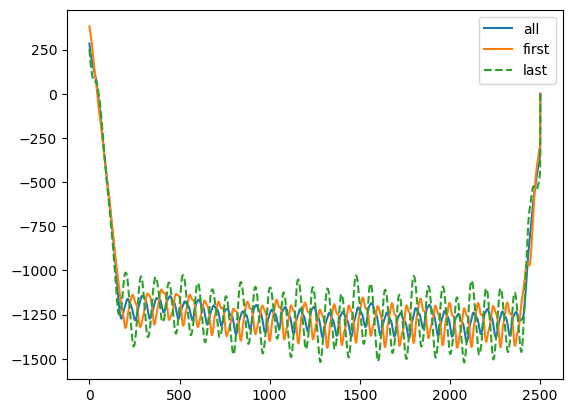

In [9]:
plt.figure()
plt.plot(mean_trace)
plt.plot(mean_trace_first)
plt.plot(mean_trace_last,'--')
plt.legend(['all', 'first', 'last'])
plt.show()

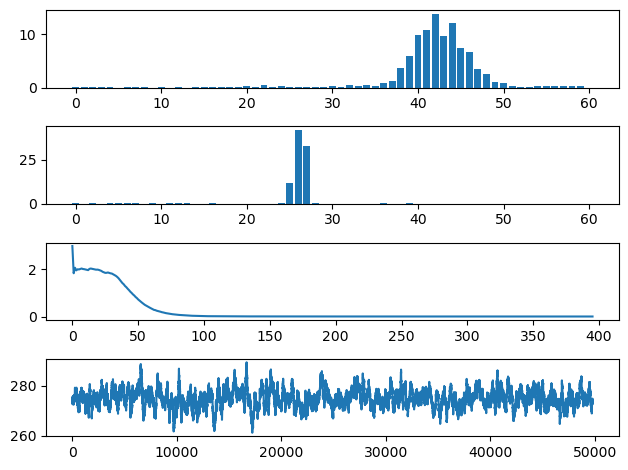

In [15]:
n_events_run_avg = np.cumsum(n_events[10000:])
n_events_run_avg = (n_events_run_avg[200:]-n_events_run_avg[:-200])/200.0

fig, axs = plt.subplots(4,1)
axs[0].bar(range(ROI_w),x_hist)
axs[1].bar(range(ROI_h),y_hist)
axs[2].plot(time_hist[time_hist!=0])
axs[3].plot(n_events_run_avg)
plt.tight_layout()
plt.show()

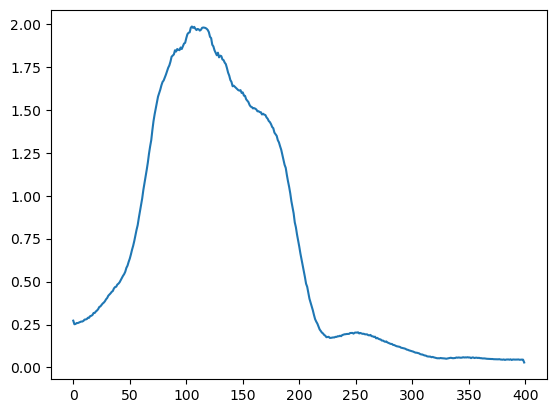

In [16]:
time_bins=range(0,401,1)
events_rate = np.zeros([len(ds), len(time_bins)-1])
imu_mat = np.zeros([len(ds), len(time_bins)-1])

# for i,(events_padded,imu) in enumerate(zip(ds, ds_imu)):
for i,events in enumerate(ds):
#     events = events_padded[:np.argmax(events_padded[:,0]),:] #removing zero-padding
    events_rate[i,:] = get_event_rate(events, bins=time_bins)
    n_samples=400
#     if len(imu['gyroscope1'])<n_samples:
#         n_samples=len(imu['gyroscope1'])
#     imu_mat[i,:n_samples]=np.array(imu['gyroscope1'][:n_samples])

mean_rates = np.mean(events_rate, axis=0)
std_rates = np.std(events_rate, axis=0)
# mean_imu = np.mean(imu_mat, axis=0)
# std_imu = np.std(imu_mat, axis=0)
# mean_imu_inverted = -1*mean_imu

plt.figure()
plt.plot(mean_rates)
plt.show()

## On events vs. Off events 